# 05 — Transformer Architectures for Battery SOH Prediction

## Models
1. **BatteryGPT** — Nano GPT-style decoder-only Transformer (2 layers, 4 heads, d_model=64)
2. **Temporal Fusion Transformer (TFT)** — Variable selection + interpretable multi-horizon
3. **iTransformer (Vanilla)** — Inverted Transformer (feature-wise attention, TensorFlow/Keras)
4. **Physics-Informed iTransformer** — Dual-head with physics constraint (λ_phy=0.3)

**Training:** Adam + CosineAnnealingLR (PyTorch) / ReduceLROnPlateau (TF), EarlyStopping

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.models.deep.transformer import BatteryGPT, TemporalFusionTransformer
from src.models.deep.lstm import train_loop, mc_dropout_predict, EarlyStopping
from src.evaluation.metrics import regression_metrics, tolerance_accuracy, build_summary_table
from src.utils.plotting import (
    plot_training_curves, plot_actual_vs_predicted, plot_residuals,
    plot_model_comparison_bars, save_fig,
)
from src.utils.config import (
    ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR,
    get_version_paths, ensure_version_dirs,
    WINDOW_SIZE, BATCH_SIZE, MAX_EPOCHS, EARLY_STOP_PATIENCE,
    TRANSFORMER_D_MODEL, TRANSFORMER_NHEAD, TRANSFORMER_LAYERS, LEARNING_RATE, DROPOUT,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
plt.style.use("seaborn-v0_8-whitegrid")

# v2 paths
v2 = get_version_paths('v2')
ensure_version_dirs('v2')

Device: cuda


## 1. Load Sequence Data

In [2]:
data = np.load(str(ARTIFACTS_DIR / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]
y_multi = data["y_multi"]
bids = data["bids_multi"]

print(f"Sequences: X={X_multi.shape}, y={y_multi.shape}")

# -- v2: intra-battery chronological split --
# For each battery, first 80% of sequences -> train, last 20% -> test
train_idx, test_idx = [], []
for bid in np.unique(bids):
    idxs = np.where(bids == bid)[0]
    n = len(idxs)
    cut = int(0.8 * n)
    train_idx.extend(idxs[:cut].tolist())
    test_idx.extend(idxs[cut:].tolist())

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train, y_train = X_multi[train_idx], y_multi[train_idx]
X_test, y_test = X_multi[test_idx], y_multi[test_idx]

# Normalize
from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {n_feat}")

Sequences: X=(1734, 32, 12), y=(1734,)
Train: 1444 | Test: 290 | Features: 12


## 2. BatteryGPT (Nano Transformer)

In [3]:
batterygpt = BatteryGPT(
    input_dim=n_feat, d_model=TRANSFORMER_D_MODEL,
    n_heads=TRANSFORMER_NHEAD, n_layers=TRANSFORMER_LAYERS,
    dropout=DROPOUT, max_len=WINDOW_SIZE * 2,
)
print(f"BatteryGPT params: {sum(p.numel() for p in batterygpt.parameters()):,}")

hist_bgpt = train_loop(
    batterygpt, train_loader, val_loader,
    max_epochs=MAX_EPOCHS, lr=LEARNING_RATE,
    patience=EARLY_STOP_PATIENCE, device=device, grad_clip=1.0,
)
print(f"Best epoch: {hist_bgpt['best_epoch']} / {hist_bgpt['epochs_trained']}")

batterygpt.eval()
with torch.no_grad():
    y_pred_bgpt = batterygpt(X_test_t.to(device)).cpu().numpy()
m_bgpt = regression_metrics(y_test, y_pred_bgpt)
m_bgpt["tol_2pct"] = tolerance_accuracy(y_test, y_pred_bgpt, 2.0)
print(f"MAE={m_bgpt['MAE']:.4f}  R²={m_bgpt['R2']:.4f}  Tol.Acc={m_bgpt['tol_2pct']:.2%}")
torch.save(batterygpt.state_dict(), str(v2["models_deep"] / "batterygpt.pt"))

BatteryGPT params: 100,865


Best epoch: 36 / 56
MAE=9.6150  R²=0.6330  Tol.Acc=17.93%


## 3. Temporal Fusion Transformer (TFT)

In [4]:
tft = TemporalFusionTransformer(
    n_features=n_feat, d_model=TRANSFORMER_D_MODEL,
    n_heads=TRANSFORMER_NHEAD, n_layers=max(1, TRANSFORMER_LAYERS - 1),
    dropout=DROPOUT,
)
print(f"TFT params: {sum(p.numel() for p in tft.parameters()):,}")

hist_tft = train_loop(
    tft, train_loader, val_loader,
    max_epochs=MAX_EPOCHS, lr=LEARNING_RATE,
    patience=EARLY_STOP_PATIENCE, device=device, grad_clip=1.0,
)

tft.eval()
with torch.no_grad():
    y_pred_tft = tft(X_test_t.to(device)).cpu().numpy()
m_tft = regression_metrics(y_test, y_pred_tft)
m_tft["tol_2pct"] = tolerance_accuracy(y_test, y_pred_tft, 2.0)
print(f"MAE={m_tft['MAE']:.4f}  R²={m_tft['R2']:.4f}  Tol.Acc={m_tft['tol_2pct']:.2%}")
torch.save(tft.state_dict(), str(v2["models_deep"] / "tft.pt"))

TFT params: 924,493


MAE=9.5381  R²=0.6548  Tol.Acc=5.52%


## 4. iTransformer (TensorFlow/Keras)
Inverted attention — attends across *features* instead of time steps, then aggregates temporally.

In [5]:
import tensorflow as tf
from src.models.deep.itransformer import build_itransformer, build_physics_itransformer

print(f"TensorFlow: {tf.__version__}")

# Build vanilla iTransformer
itrans = build_itransformer(
    seq_len=seq_len, n_features=n_feat,
    d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD,
    n_blocks=TRANSFORMER_LAYERS, dropout=DROPOUT,
)
itrans.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
               loss="mse", metrics=["mae"])
itrans.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=EARLY_STOP_PATIENCE, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10),
]
hist_itrans = itrans.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1,
)

y_pred_it = itrans.predict(X_test, verbose=0).flatten()
m_it = regression_metrics(y_test, y_pred_it)
m_it["tol_2pct"] = tolerance_accuracy(y_test, y_pred_it, 2.0)
print(f"iTransformer — MAE={m_it['MAE']:.4f}  R²={m_it['R2']:.4f}  Tol.Acc={m_it['tol_2pct']:.2%}")
itrans.save(str(v2["models_deep"] / "itransformer.keras"))

TensorFlow: 2.20.0


Model: "iTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 32, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_proj (Dense)              │ (None, 32, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_mha_0 (FeatureWiseMHA)     │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_mha_0 (TokenWiseMHA)      │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_ff_0 (Conv1DFeedForward)   │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_mha_1 (FeatureWiseMHA)     │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_mha_1 (TokenWiseMHA)      │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_ff_1 (Conv1DFeedForward)   │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ soh_output (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,209 (493.00 KB)

 Trainable params: 126,209 (493.00 KB)

...

41/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 27.6077 - mae: 4.0822

43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 27.6717 - mae: 4.0850

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 27.7275 - mae: 4.0873

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 28.9288 - mae: 4.1372 - val_loss: 424.8767 - val_mae: 15.6956 - learning_rate: 5.0000e-04


iTransformer — MAE=9.3568  R²=0.5923  Tol.Acc=13.10%


## 5. Physics-Informed iTransformer
Dual-head model with auxiliary physics branch predicting ΔQ (capacity fade slope).
Joint loss = MSE_soh + λ_phy × MSE_physics

In [6]:
phys_itrans = build_physics_itransformer(
    seq_len=seq_len, n_features=n_feat,
    d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD,
    n_blocks=TRANSFORMER_LAYERS, dropout=DROPOUT, lambda_phy=0.3,
)
phys_itrans.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={"soh_ml": "mse", "soh_phy": "mse"},
    loss_weights={"soh_ml": 1.0, "soh_phy": 0.3},
    metrics={"soh_ml": "mae"},
)
phys_itrans.summary()

# Fresh callbacks — reusing stale EarlyStopping contaminates state
phys_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_soh_ml_loss", patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True, verbose=1, mode="min",
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_soh_ml_loss", factor=0.5, patience=10, verbose=1, mode="min",
    ),
]

# Physics target: ΔQ = y[t] - y[t-1] approximated as difference of SOH
delta_q_train = np.gradient(y_train)
delta_q_test = np.gradient(y_test)

hist_phys = phys_itrans.fit(
    X_train, {"soh_ml": y_train, "soh_phy": delta_q_train},
    validation_data=(X_test, {"soh_ml": y_test, "soh_phy": delta_q_test}),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=phys_callbacks, verbose=1,
)

y_pred_phys = phys_itrans.predict(X_test, verbose=0)
if isinstance(y_pred_phys, (list, tuple)):
    y_pred_phys_soh = y_pred_phys[0].flatten()
else:
    y_pred_phys_soh = y_pred_phys.flatten()

m_phys = regression_metrics(y_test, y_pred_phys_soh)
m_phys["tol_2pct"] = tolerance_accuracy(y_test, y_pred_phys_soh, 2.0)
print(f"Physics iTransformer — MAE={m_phys['MAE']:.4f}  R²={m_phys['R2']:.4f}  Tol.Acc={m_phys['tol_2pct']:.2%}")
phys_itrans.save(str(v2["models_deep"] / "physics_itransformer.keras"))

Model: "PhysicsInformed_iTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 32, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_proj (Dense)     │ (None, 32, 64)    │        832 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_feat_0           │ (None, 32, 64)    │      8,480 │ ml_proj[0][0]     │
│ (FeatureWiseMHA)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_token_0          │ (None, 32, 64)    │     16,768 │ ml_feat_0[0][0]   │
│ (TokenWiseMHA)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_ff_0             │ (None, 32, 64)    │     33,216 │ ml_token_0[0][0]  │
│ (Conv1DFeedForward) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_feat_1           │ (None, 32, 64)    │      8,480 │ ml_ff_0[0][0]     │
│ (FeatureWiseMHA)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_token_1          │ (None, 32, 64)    │     16,768 │ ml_feat_1[0][0]   │
│ (TokenWiseMHA)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_ff_1             │ (None, 32, 64)    │     33,216 │ ml_token_1[0][0]  │
│ (Conv1DFeedForward) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_cum_current     │ (None, 32, 1)     │          0 │ input_seq[0][0]   │
│ (AbsCumCurrentLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_gap              │ (None, 64)        │          0 │ ml_ff_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phy_gap             │ (None, 1)         │          0 │ abs_cum_current[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_fc (Dense)       │ (None, 128)       │      8,320 │ ml_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phy_fc1 (Dense)     │ (None, 64)        │        128 │ phy_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 128)       │          0 │ ml_fc[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phy_fc2 (Dense)     │ (None, 32)        │      2,080 │ phy_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soh_ml (Dense)      │ (None, 1)         │        129 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soh_phy (Dense)     │ (None, 1)         │         33 │ phy_fc2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,450 (501.76 KB)

 Trainable params: 128,450 (501.76 KB)

 Non-trainable params: 0 (0.00 B)

...


Epoch 46: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 33.6058 - soh_ml_loss: 28.1854 - soh_ml_mae: 4.0359 - soh_phy_loss: 17.3961 - val_loss: 252.2979 - val_soh_ml_loss: 223.7666 - val_soh_ml_mae: 13.1131 - val_soh_phy_loss: 17.6891 - learning_rate: 2.5000e-04


Epoch 46: early stopping


Restoring model weights from the end of the best epoch: 26.


Physics iTransformer — MAE=12.1375  R²=0.4179  Tol.Acc=7.93%


## 6. Training Curves & Comparison

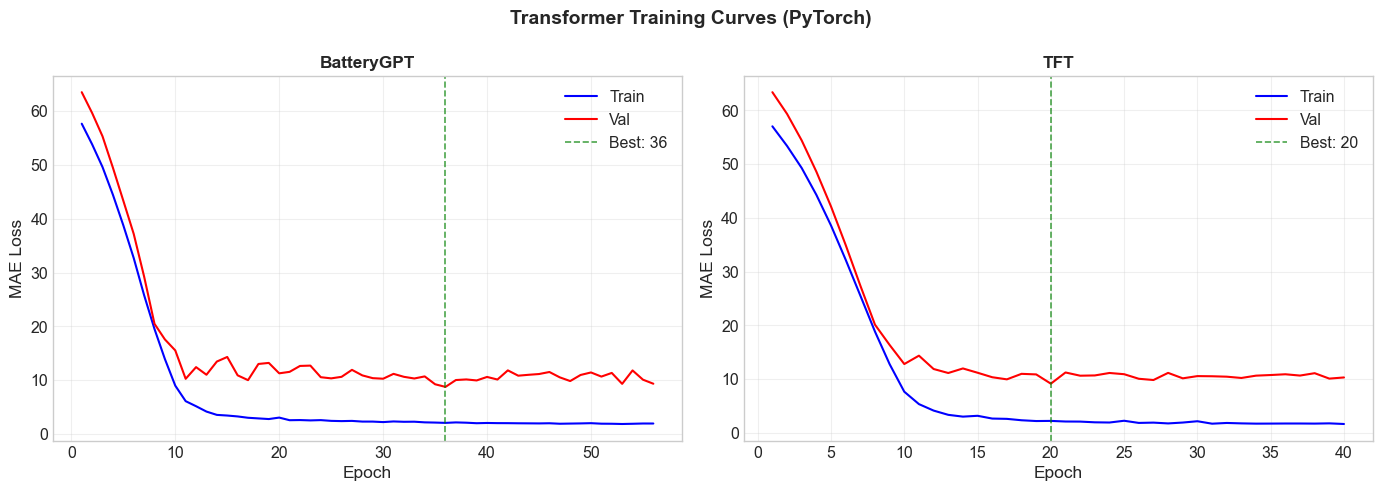

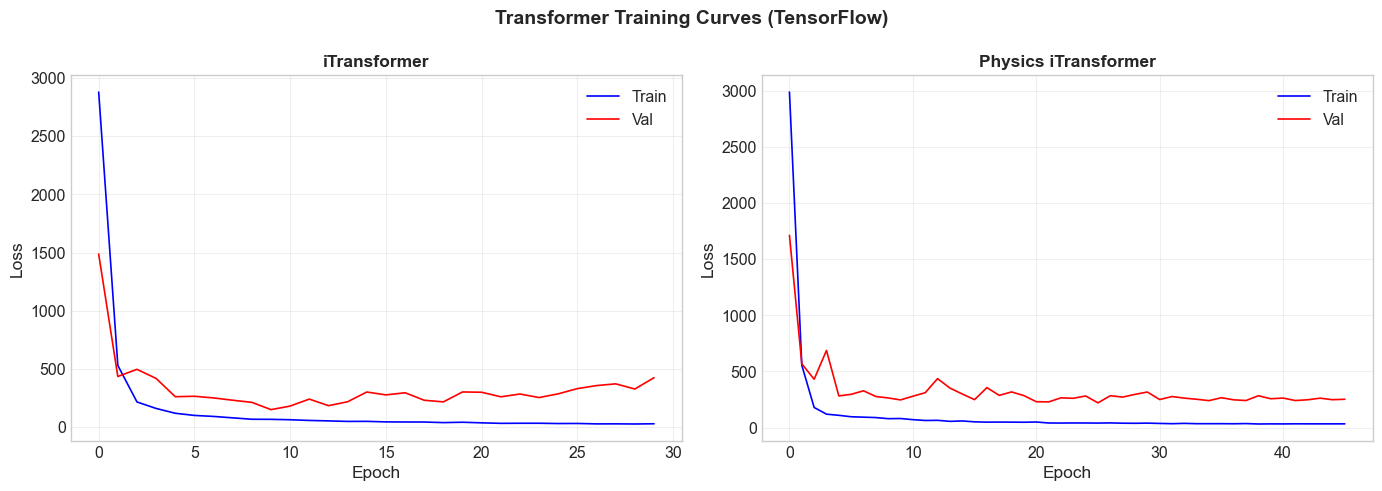

In [7]:
# PyTorch training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, hist) in zip(axes, [("BatteryGPT", hist_bgpt), ("TFT", hist_tft)]):
    epochs = range(1, len(hist["train_losses"]) + 1)
    ax.plot(epochs, hist["train_losses"], "b-", linewidth=1.5, label="Train")
    ax.plot(epochs, hist["val_losses"], "r-", linewidth=1.5, label="Val")
    ax.axvline(x=hist["best_epoch"], color="green", linestyle="--", alpha=0.7, label=f"Best: {hist['best_epoch']}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE Loss")
    ax.set_title(name, fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Transformer Training Curves (PyTorch)", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v2_transformer_pt_training_curves"); plt.show()

# Keras training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, hist) in zip(axes, [("iTransformer", hist_itrans), ("Physics iTransformer", hist_phys)]):
    ax.plot(hist.history["loss"], "b-", label="Train")
    ax.plot(hist.history["val_loss"], "r-", label="Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(name, fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Transformer Training Curves (TensorFlow)", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v2_transformer_tf_training_curves"); plt.show()

## 7. Summary Table

In [8]:
all_results = {
    "BatteryGPT": m_bgpt,
    "TFT": m_tft,
    "iTransformer": m_it,
    "Physics iTransformer": m_phys,
}
summary = build_summary_table(all_results).sort_values("R2", ascending=False)
display(summary.round(4))
summary.to_csv(v2["results"] / "v2_transformer_soh_results.csv")
print("Saved to artifacts/transformer_soh_results.csv")
print(f"\nBest: {summary.index[0]} — R² = {summary.iloc[0]['R2']:.4f}, MAE = {summary.iloc[0]['MAE']:.4f}")

,MAE,MSE,RMSE,R2,MAPE,tol_2pct
model,,,,,,
TFT,9.5381,127.3166,11.2835,0.6548,18.9802,0.0552
BatteryGPT,9.6150,135.3473,11.6339,0.6330,15.4442,0.1793
iTransformer,9.3568,150.3506,12.2618,0.5923,14.4908,0.1310
Physics iTransformer,12.1375,214.6543,14.6511,0.4179,24.9853,0.0793


Saved to artifacts/transformer_soh_results.csv

Best: TFT — R² = 0.6548, MAE = 9.5381
